# A three-layer Earth: from a Love number to layer compliances

Notebooks 1–2 used a single sphere. Here we add interfaces — a mockup PREM (**solid inner core ·
fluid outer core · solid mantle**, constant $\rho,\kappa,\mu$ per layer) — and put
`potential_forcing` to work. It is one body-force builder with three knobs: a potential $\Phi(r)$,
an amplitude, and a **layer mask** that picks which layers feel it.

The arc: wobble the **whole planet** and its equatorial moment of inertia changes by an amount set
by the tidal Love number $k_2$ (§4). Then restrict the *same* forcing to a **single layer** at a
time — the mask — so each layer wobbles on its own, turning that one number into the full
$3\times3$ matrix of layer compliances (§5).

In [1]:
using Pkg; Pkg.activate(@__DIR__)
using Melinoe, ApproxFun, PyPlot, Printf, LinearAlgebra
Ω = 7.2921e-5; ℓ = 2

# mockup PREM: solid inner core | fluid outer core | solid mantle
domains = [0.0..0.35, 0.35..0.55, 0.55..1.0]
ρphys   = [13.0, 10.0, 4.5]              # physical densities [g/cm³], PREM-ish
# normalise to the volume mean, so ρ is in units of ρ̄ and g(1) = 1 exactly
vol(a, b) = (b^3 - a^3)/3
ρ̄ = 3*sum(ρphys[i]*vol(leftendpoint(domains[i]), rightendpoint(domains[i])) for i in 1:3)

m = build_model("mock3", domains, [[ρphys[i]/ρ̄] for i in 1:3],
                [r->4.0, r->3.0, r->1.5],          # bulk moduli κ  (/p_unit)
                [r->1.5, r->0.0, r->0.8],          # shear moduli μ  (OC: 0 ⇒ fluid)
                [40, 40, 40]; R_SI = 6371e3, ρ̄_SI = ρ̄*1000, Ω_SI = Ω)
@printf("volume-mean density ρ̄ = %.3f g/cm³   ⇒   g(surface) = %.4f\n\n", ρ̄, m.layers[3].g₀(1.0))
for (i, nm) in enumerate(("inner core", "outer core", "mantle"))
    l = m.layers[i]
    @printf("%-11s [%.2f, %.2f]   %s\n", nm, leftendpoint(l.domain), rightendpoint(l.domain),
            is_fluid(l) ? "FLUID" : "solid")
end


  Activating 

volume-mean density ρ̄ = 5.544 g/cm³   ⇒   g(surface) = 1.0000

inner core  [0.00, 0.35]   solid


project at `~/code/ge-julia`


outer core  [0.35, 0.55]   FLUID
mantle      [0.55, 1.00]   solid


## 1 · The model

Density is a step function (piecewise constant); gravity $g(r)$ is *derived* from it
and is continuous but kinked at each interface.


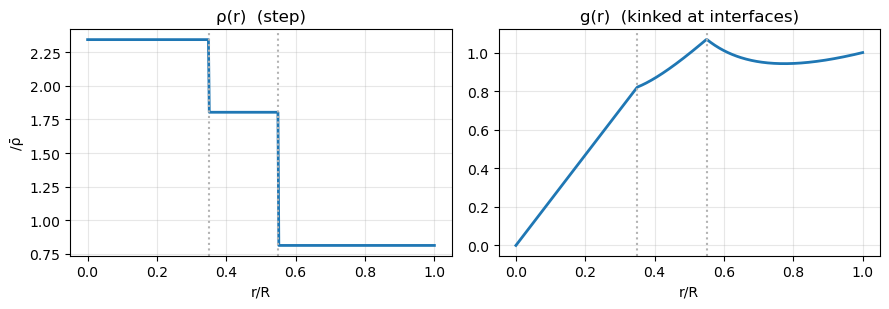

In [2]:
rr = range(0, 1, length = 400)
ρ(r) = (for l in m.layers; r ≤ rightendpoint(l.domain)+1e-9 && return l.ρ₀(r); end)
g(r) = (for l in m.layers; r ≤ rightendpoint(l.domain)+1e-9 && return l.g₀(r); end)
fig, ax = subplots(1, 2, figsize = (9, 3.2))
ax[1].plot(rr, ρ.(rr), lw = 2); ax[1].set_title("ρ(r)  (step)"); ax[1].set_ylabel("/ρ̄")
ax[2].plot(rr, g.(rr), lw = 2); ax[2].set_title("g(r)  (kinked at interfaces)")
for a in ax; a.set_xlabel("r/R"); a.grid(alpha=0.3); for x in (0.35, 0.55); a.axvline(x, color="0.7", ls=":"); end; end
tight_layout(); gcf()


## 2 · Assembly — now with interfaces

Three layers gives the same $3N_{\rm tot}\times3N_{\rm tot}$ block matrix as notebook 1, plus
junction rows at the two interior interfaces (ICB, CMB) on top of the surface conditions.

One wrinkle: the outer core is a **static fluid**, which is ill-posed against solid walls
(notebook 2). `dahlenize(m)` returns an ordinary `PlanetModel` with the Dahlen closure baked in,
so `assemble_planet` builds `A` from it like any other model — one assembler, three layers, a
uniform $(U,V,\delta\phi)$ block per layer.

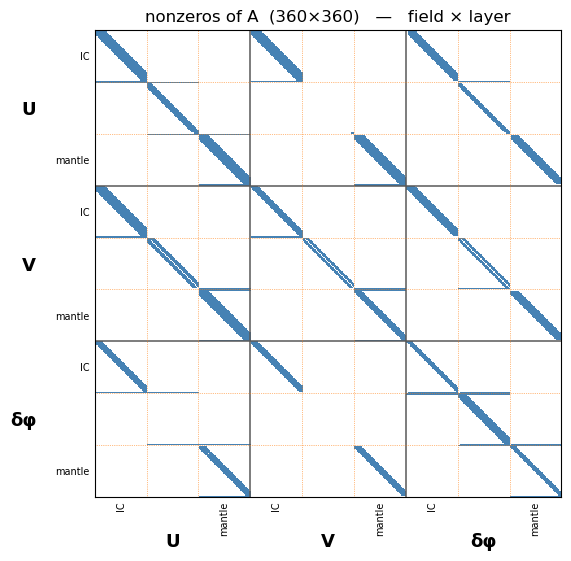

In [3]:
mm = dahlenize(m)                     # static fluid ⇒ Dahlen closure (notebook 2)
A, _, ops, ns, jr = assemble_planet(mm.layers, ℓ)
Ntot = sum(ns); cumN = cumsum([0; ns])
fig, ax = subplots(figsize = (5.8, 5.8))
bw = PyPlot.matplotlib.colors.ListedColormap(["white", "steelblue"])
ax.imshow(Float64.(Matrix(A) .!= 0); cmap = bw, vmin = 0, vmax = 1, interpolation = "nearest")

# block guides: fields (gray solid) and layers (orange dotted), on both axes
for b in (Ntot, 2Ntot); ax.axvline(b-0.5, color="0.35", lw=1.1); ax.axhline(b-0.5, color="0.35", lw=1.1); end
for cc in cumsum(ns)[1:2], k in 0:2
    ax.axvline(k*Ntot+cc-0.5, color="C1", lw=0.5, ls=":"); ax.axhline(k*Ntot+cc-0.5, color="C1", lw=0.5, ls=":")
end

# two-level labels: fields (U,V,δφ) bold & outer, layers (IC,OC,mantle) small & inner
fields = ["U", "V", "δφ"];  layers = ["IC", "OC", "mantle"]
fieldc = [f*Ntot + Ntot/2 - 0.5           for f in 0:2]                    # field-block centres
layerc = [f*Ntot + (cumN[i]+cumN[i+1])/2 - 0.5 for f in 0:2 for i in 1:3] # layer sub-block centres
llab   = repeat(layers, 3)
ax.set_xticks(fieldc); ax.set_xticklabels(fields, fontsize = 13, fontweight = "bold")
ax.set_yticks(fieldc); ax.set_yticklabels(fields, fontsize = 13, fontweight = "bold")
ax.set_xticks(layerc, minor = true); ax.set_xticklabels(llab, minor = true, fontsize = 7, rotation = 90)
ax.set_yticks(layerc, minor = true); ax.set_yticklabels(llab, minor = true, fontsize = 7)
ax.tick_params(axis = "x", which = "major", length = 0, pad = 26)   # push field labels past the layer labels
ax.tick_params(axis = "y", which = "major", length = 0, pad = 42)
ax.tick_params(which = "minor", length = 0)
ax.set_title("nonzeros of A  ($(3Ntot)×$(3Ntot))   —   field × layer")
tight_layout(); gcf()

**Reading the pattern.** Each diagonal band is a spectral operator (a field's radial equation); each
horizontal line is a boundary or interface (junction) row. The lone **off-band cluster at the CMB**
is the signature of `dahlenize`: a static fluid carries no interior equation for its displacement —
it collapses to a single closed equation for $\delta\phi$ (density is slaved to the potential,
$\delta\rho=\rho_0'(\delta\phi+\Phi)/g_0$), so `U,V` drop out of the outer-core interior. The core
therefore hands its motion to the mantle *only* through **direct junction rows** at the interface —
that off-diagonal coupling.

## 3 · Forcing a chosen region

`potential_forcing(ops, ns; ℓ, potential, amplitude, layer_mask, jrhs)` builds the RHS.
Three knobs:

- **`potential`** $\Phi(r)$ — the *type*. A tide and a centrifugal wobble both use $r^\ell$;
  an inner-core tilt uses $-(2/3)\varepsilon r g$.
- **`amplitude`** — the scale (tide: $1$; centrifugal wobble: $\hat\Omega^2/3$).
- **`layer_mask`** — *which layers feel it*. This is how a region is targeted.

These amplitudes fix the normalization of the $\ell{=}2$ harmonic,
$Y_2^1=\tfrac32\sin\theta\cos\theta\,e^{i\varphi}$, and §4 keeps that convention throughout. The
choice is arbitrary — rescaling $Y_2^1$ shifts the intermediate constants but leaves every physical
compliance unchanged (the code confirms this by sweeping the scale).

Apply the centrifugal potential to the whole body, then the outer core alone, then the
inner core alone. The mask simply zeroes the RHS outside the chosen region:

In [4]:
Ω̂² = (Ω / m.ω_unit)^2
force(mask) = potential_forcing(ops, ns; ℓ, amplitude = Ω̂²/3, layer_mask = mask, jrhs = jr)
masks = ("whole body" => [true,true,true], "outer core" => [false,true,false],
         "inner core" => [true,false,false])
cumN = cumsum([0; ns])
blocknorm(f, i) = norm(f[cumN[i]+1 : cumN[i+1]])          # ‖f‖ in layer i's U-rows
@printf("%-12s %11s %11s %11s\n", "mask", "IC", "OC", "mantle")
for (tag, mk) in masks
    f = force(mk)
    @printf("%-12s %11.2e %11.2e %11.2e\n", tag, blocknorm(f,1), blocknorm(f,2), blocknorm(f,3))
end
println("\nthe mask zeroes the RHS outside the chosen region — that is all it does.")


mask                  IC          OC      mantle
whole body      5.61e-06    6.94e-05    7.54e-04
outer core      3.29e-11    6.94e-05    0.00e+00
inner core      5.61e-06    0.00e+00    0.00e+00

the mask zeroes the RHS outside the chosen region — that is all it does.


## 4 · The whole planet wobbles: a Love number

Spin the planet off its figure axis. The forcing is an equatorial ($\ell{=}2,\,m{=}1$) perturbation,
so its two equatorial components combine into one complex number — and so does the response. Write
the **wobble** (rotation axis relative to the figure) as $\tilde m = m_1 + i\,m_2$ and any external
**tidal potential** as $\tilde\phi = \phi_1 + i\,\phi_2$. The equatorial moment of inertia
$\tilde c_3 = \delta I_{13} + i\,\delta I_{23}$ responds to the net forcing $\tilde\phi-\tilde m$
through the **compliance** $\kappa$:

$$\tilde c_3 = A\,\kappa\,(\tilde\phi-\tilde m), \qquad A = \tfrac{8\pi}{3}\int_0^R\rho_0 r^4dr = \tfrac{8\pi}{3}\hat A .$$

The demo below applies a unit forcing $\tilde\phi-\tilde m=1$, so $\kappa=\tilde c_3/A$. Reading
$\tilde c_3$ off the solved fields $(U,\delta\phi)$ takes three steps, in the harmonic normalization
fixed in §3.

**1. Inertia tensor.** $\displaystyle I_{13}+iI_{23} = -\int_V\rho\,(x+iy)\,z\,dV .$

**2. Its increment.** Take $\delta\rho$ **Eulerian** (the change at a fixed point): interface motion
is then automatic. As an interface sweeps outward by $u_r$, a fixed point it crosses picks up the
density jump there — a thin shell of swept mass — so the volume integral already accounts for every
internal interface, and the only surface term left is the outer boundary (Reynolds transport, with
$\delta$ playing the role of $\partial_t$ and $\mathbf u$ the flow):
$$\delta\!\int_V\rho\,w\,dV = \int_{V_0}\delta\rho\,w\,dV + \oint_{\partial V_0}\rho_0\,w\,(\mathbf u\!\cdot\!\hat n)\,dS .$$
Since $(x{+}iy)z = r^2\sin\theta\cos\theta\,e^{i\varphi}=\tfrac23 r^2 Y_2^1$, put $w=-\tfrac23 r^2 Y_2^1$
and $\mathbf u\!\cdot\!\hat n=U\,Y_2^1$; both integrals reduce to their radial parts times the same
angular factor $\tfrac23\!\int|Y_2^1|^2\,d\Omega=\tfrac{4\pi}{5}$:
$$\tilde c_3 = -\frac{4\pi}{5}\Big(\underbrace{\int_0^R\delta\rho\,r^4dr}_{\text{volume}} + \underbrace{\big[\rho_0 r^4U\big]_0^R}_{\text{outer boundary}}\Big).$$

**3. Poisson kills $\delta\rho$.** The volume integrand is a total derivative: with
$\nabla^2\delta\phi=3\delta\rho$ and $r^4\nabla^2\delta\phi=\tfrac{d}{dr}(r^4\delta\phi'-2r^3\delta\phi)$,
it integrates to $\tfrac13[r^4\delta\phi'-2r^3\delta\phi]_0^R$. Combined with the boundary term
$[\rho_0 r^4U]_0^R$,
$$\tilde c_3 = -\frac{4\pi}{15}\,[F]_0^R, \qquad F = r^4\delta\phi' + 3\rho\,r^4U - 2r^3\delta\phi .$$

For a whole-planet wobble, evaluate $[F]$ at the surface. Outside the body only $\delta\phi$ survives
(it falls off as $r^{-3}$), so $[F]=F(R)=-5\delta\phi(R)$ and

$$\kappa = \frac{\tilde c_3}{A} = \frac{\delta\phi(R)}{2\hat A} .$$

The surface potential $\delta\phi(R)$ that an $r^2$ forcing induces over the *whole* Earth is exactly
what the tidal **Love number** $k_2$ measures. So the equatorial-inertia response of a whole-planet
wobble is that Love number:

$$\kappa = \frac{\hat\Omega^2}{6\,\hat A}\,k_2 .$$

The cell below forces the whole body and checks both readings agree.

In [5]:
# read fields U (f=0) and δφ (f=2) from a solution vector, per layer
cumN = cumsum([0; ns])
fld(f,i,x) = Fun(ops[i].S, x[f*Ntot + cumN[i]+1 : f*Ntot + cumN[i+1]])
Â(i) = sum(Fun(r -> mm.layers[i].ρ₀(r)*r^4, Chebyshev(mm.layers[i].domain)))   # moment-of-inertia integral ∫ρ₀r⁴dr
Ât = Â(1) + Â(2) + Â(3)
Ω̂² = (Ω/mm.ω_unit)^2

# wobble the WHOLE planet; read κ from the induced surface potential δφ(R)
x  = A \ potential_forcing(ops, ns; ℓ, amplitude = Ω̂²/3, layer_mask = [true,true,true], jrhs = jr)
κ  = fld(2,3,x)(1.0) / (2Ât)          # κ = δφ(R)/(2Â)
k2 = love_numbers(m).k
@printf("whole-planet wobble:\n")
@printf("  κ = δφ(R)/(2Â)   = %.4e\n", κ)
@printf("  (Ω̂²/6Â)·k₂       = %.4e     (Love number k₂ = %.4f)\n", Ω̂²/(6Ât)*k2, k2)

whole-planet wobble:
  κ = δφ(R)/(2Â)   = 8.7893e-04
  (Ω̂²/6Â)·k₂       = 8.7893e-04     (Love number k₂ = 0.2657)


## 5 · Each layer wobbles on its own: the compliance matrix

The $r^2$ forcing above shook the whole planet at once. But `potential_forcing`'s **layer mask** can
apply it to *one region at a time* — wobbling the inner core, or the outer core, on its own. Each run
is a legitimate physical question, read the same way as §4, except now we want each region's
*individual* share of $\tilde c_3$, not just the whole-planet total.

That split is clean because $F$ is **continuous** across every interface: the $3\rho r^4U$ term
cancels the jump in $r^4\delta\phi'$ (at an interface $[\delta\phi']=-3[\rho_0]U$). So $[F]$ across a
single region — the difference of its two endpoint values — is exactly that region's contribution to
$\tilde c_3$, with nothing leaking in from its neighbours.

Number the regions by the dictionary $1={}$whole Earth, $2=f$ (outer/fluid core), $3=s$ (inner/solid
core). Reading region $i$'s share from the solution forced in region $j$ gives a $3\times3$ matrix
$S_{ij}$:

$$S_{ij} = -\frac{[F]_{\partial i}}{10\,\hat A_i}\bigg|_{\text{wobble in }j}, \qquad \hat A_i=\int_i\rho_0 r^4dr .$$

| $S_{ij}$ | $j=1$ (whole) | $j=2$ ($f$) | $j=3$ ($s$) |
|---|---|---|---|
| $i=1$ (whole) | $S_{11}=\kappa$ | $S_{12}=\xi$ | $S_{13}=\zeta$ |
| $i=2$ ($f$) | $S_{21}=\gamma$ | $S_{22}=\beta$ | $S_{23}=\delta$ |
| $i=3$ ($s$) | $S_{31}=\theta$ | $S_{32}=\chi$ | $S_{33}=\nu$ |

(the Greek names are the SIC / Mathews–Herring–Buffett parameters.)

As a linear response, the three regional moments are this matrix acting on the three forcings — §4's
relation $\tilde c_3=A\kappa(\tilde\phi-\tilde m)$ promoted to a $3\times3$ system. The tide
$\tilde\phi$ is a **whole-planet** field, so it appears only through the whole-Earth column ($j{=}1$),
riding with the whole-body wobble $\tilde m$; forcing the fluid or solid core carries no tide, so
those columns reduce to the differential wobbles $-\tilde m_f,\,-\tilde m_s$ alone. With
$A=\tfrac{8\pi}{3}\hat A$, $A_f=\tfrac{8\pi}{3}\hat A_f$, $A_s=\tfrac{8\pi}{3}\hat A_s$,

$$\begin{aligned}
\tilde c_3\phantom{^{f}} &= A\big[\,\kappa\,(\tilde\phi-\tilde m) - \xi\,\tilde m_f - \zeta\,\tilde m_s\,\big],\\
\tilde c_3^{\,f} &= A_f\big[\,\gamma\,(\tilde\phi-\tilde m) - \beta\,\tilde m_f - \delta\,\tilde m_s\,\big],\\
\tilde c_3^{\,s} &= A_s\big[\,\theta\,(\tilde\phi-\tilde m) - \chi\,\tilde m_f - \nu\,\tilde m_s\,\big].
\end{aligned}$$

A pure whole-body wobble (only the $\tilde\phi-\tilde m$ term) reproduces §4's Love number,
$\tilde c_3 = A\kappa(\tilde\phi-\tilde m)$. The whole–whole entry $S_{11}=\kappa$ is that tidal Love
number; the other eight involve a core — as reader, forcing, or both — and have no global counterpart.
Two properties the code checks:

- **Reciprocity** — $\hat A_i S_{ij}=\hat A_j S_{ji}$ (Betti's theorem), which holds *only* with the
  well-posed interfaces `dahlenize` provides; the field-by-field identity is the companion
  **`betti_reciprocity`** notebook.
- **Normalization** — the constants $10$ and $2$ carry the §3 harmonic scaling; sweeping it leaves
  every $S_{ij}$ unchanged (they are physical).

In [6]:
F(i,r,x) = (U=fld(0,i,x); φ=fld(2,i,x);  r^4*φ'(r) + 3*mm.layers[i].ρ₀(r)*r^4*U(r) - 2*r^3*φ(r))

# Wobble each region on its own — layer_mask restricts the forcing — and read each region's share.
# Matrix index dictionary: 1 = whole Earth, 2 = f (outer/fluid core), 3 = s (inner/solid core).
# N is the (arbitrary) harmonic normalization of §3; N = 3/2 gives the clean 2Â, 10Â.
function Smatrix(N)
    force(mask) = A \ potential_forcing(ops, ns; ℓ, amplitude = Ω̂²/(2N), layer_mask = mask, jrhs = jr)
    readers = (x ->  fld(2,3,x)(1.0)              / ((3/N)*Ât),      # i = 1  whole Earth
               x -> -(F(2,0.55,x) - F(2,0.35,x))  / ((15/N)*Â(2)),   # i = 2  f  (outer/fluid core)
               x -> -(F(1,0.35,x) - F(1,0.00,x))  / ((15/N)*Â(1)))   # i = 3  s  (inner/solid core)
    sols = (force([true,true,true]), force([false,true,false]), force([true,false,false]))  # j = 1/2/3
    [readers[i](sols[j]) for i in 1:3, j in 1:3]
end

name = ["κ" "ξ" "ζ"; "γ" "β" "δ"; "θ" "χ" "ν"]
S = Smatrix(3/2)
@printf("%-8s %13s %13s %13s\n", "S_ij", "j=1 whole", "j=2 f", "j=3 s")
for i in 1:3
    @printf("%-8s", ("1 whole","2 f","3 s")[i])
    for j in 1:3; @printf("   %s=%+.3e", name[i,j], S[i,j]); end; println()
end

println("\nthe normalization N is arbitrary — same matrix for any N (§3):")
for N in (1.0, sqrt(15/(8π)), 7.3)                # 3/2 clean, √(15/8π) fully normalized, 7.3 random
    @printf("   N = %-7.4f  max|S(N) − S(3/2)| = %.1e\n", N, maximum(abs, Smatrix(N) .- S))
end

c = sic_compliances(mm; ic_layer=1, oc_layer=2, Ω_SI=Ω)
ref = [c.κ c.ξ c.ζ; c.γ c.β c.δ; c.θ c.χ c.ν]
@printf("\nmatches sic_compliances (max diff %.0e);  reciprocity Â·ξ = Â_f·γ: %.3e = %.3e\n",
        maximum(abs, S .- ref), Ât*c.ξ, Â(2)*c.γ)

# reciprocity (Betti) needs the well-posed interfaces dahlenize gives — the plain model breaks it:
cp = sic_compliances(m; ic_layer=1, oc_layer=2, Ω_SI=Ω)
@printf("Betti Â·ξ − Â_f·γ :  plain %.1e   dahlenized %.1e\n", cp.recip.ξγ, c.recip.ξγ)

S_ij         j=1 whole         j=2 f         j=3 s
1 whole    κ=+8.789e-04   ξ=+1.835e-04   ζ=+4.653e-07
2 f        γ=+1.951e-03   β=+5.975e-04   δ=-9.597e-06
3 s        θ=+3.266e-05   χ=-6.336e-05   ν=+8.517e-05

the normalization N is arbitrary — same matrix for any N (§3):
   N = 1.0000   max|S(N) − S(3/2)| = 2.1e-16
   N = 0.7725   max|S(N) − S(3/2)| = 1.3e-16
   N = 7.3000   max|S(N) − S(3/2)| = 9.0e-17

matches sic_compliances (max diff 2e-19);  reciprocity Â·ξ = Â_f·γ: 3.172e-05 = 3.172e-05
Betti Â·ξ − Â_f·γ :  plain -8.2e-05   dahlenized -6.0e-15
